In [ ]:
# ノートブック上で
!pip install -r requirements.txt

In [4]:
import os
import time
import json

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import confusion_matrix, recall_score
from torch.utils.data import DataLoader
from tqdm import tqdm

from pointnet2 import PointNet2
from semanticstf_dataset_v2 import SemanticSTFDataset
from inference_pointnet2 import run_inference

In [4]:
# ───────────────────────────────
# 設定
# ───────────────────────────────
root = "./SemanticSTF" 
num_points = 16384
batch_size = 2
epochs = 50
lr = 1e-3
weight_decay = 1e-4  # 正則化を追加

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# CUDAメモリの最適化設定
if torch.cuda.is_available():
    torch.cuda.empty_cache()  # キャッシュをクリア
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print(f"Initial Allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
    print(f"Initial Reserved: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")

# ───────────────────────────────
# Dataset / DataLoader
# ───────────────────────────────
train_dataset = SemanticSTFDataset(root, split="train", num_points=num_points)
val_dataset = SemanticSTFDataset(root, split="val", num_points=num_points)

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=4  # 4 → 2 に削減
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False, num_workers=4  # 4 → 2 に削減
)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

# ───────────────────────────────
# Model
# ───────────────────────────────
model = PointNet2(in_dim=5, num_classes=2, num_points=num_points).to(device)

# クラス不均衡対策：ノイズ点（クラス1）に重みを付ける
# データセット全体のクラス比率を調べてから設定するのが理想的
# ここでは仮にノイズ点が少ないと仮定して重み10倍に設定
class_weights = torch.tensor([1.0, 10.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

# Learning rate scheduler（オプション）
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

Using: cuda
GPU Memory: 6.00 GB
Initial Allocated: 6.01 GB
Initial Reserved: 6.02 GB
Train samples: 1000
Val samples: 250


In [3]:
# ───────────────────────────────
# 学習開始時刻を記録
# ───────────────────────────────
# start_time = time.time()

# ───────────────────────────────
# Training Loop
# ───────────────────────────────
best_val_loss = float('inf')

# 学習曲線用のリスト
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    total_correct = 0
    total_points = 0

    # tqdmで進捗バーを表示
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", ncols=100)
    
    for i, (points, labels) in enumerate(pbar):
        points = points.to(device)  # (B, N, 5)
        labels = labels.to(device)  # (B, N)

        optimizer.zero_grad()

        # Forward
        logits = model(points)  # (B, N, 2)
        logits = logits.permute(0, 2, 1)  # (B, 2, N) ← CE はこの形を要求

        # Loss
        loss = criterion(logits, labels)

        # Backprop
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        
        # Accuracy
        preds = logits.argmax(dim=1)  # (B, N)
        total_correct += (preds == labels).sum().item()
        total_points += labels.numel()
        
        # 進捗バーに現在の統計を表示
        current_loss = total_loss / (i + 1)
        current_acc = total_correct / total_points
        pbar.set_postfix({
            'loss': f'{current_loss:.4f}',
            'acc': f'{current_acc:.4f}'
        })
        
        # メモリ解放（重要！）
        del points, labels, logits, preds, loss
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    avg_train_loss = total_loss / len(train_loader)
    train_acc = total_correct / total_points
    train_losses.append(avg_train_loss)  # 学習曲線用に記録
    train_accs.append(train_acc)  # 精度も記録
    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")

    # ───────────────────────────────
    # Validation
    # ───────────────────────────────
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    
    # クラスごとの精度を追跡
    class_correct = [0, 0]
    class_total = [0, 0]

    # Validationにも進捗バーを追加
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]  ", ncols=100)
    
    with torch.no_grad():
        for points, labels in val_pbar:
            points = points.to(device)
            labels = labels.to(device)

            logits = model(points)
            logits = logits.permute(0, 2, 1)

            loss = criterion(logits, labels)
            val_loss += loss.item()

            # accuracy（全点で計算）
            preds = logits.argmax(dim=1)  # (B, N)
            correct += (preds == labels).sum().item()
            total += labels.numel()
            
            # クラスごとの精度
            for c in range(2):
                class_mask = (labels == c)
                class_correct[c] += ((preds == labels) & class_mask).sum().item()
                class_total[c] += class_mask.sum().item()
            
            # メモリ解放（重要！）
            del points, labels, logits, preds, loss
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct / total
    val_losses.append(avg_val_loss)  # 学習曲線用に記録
    val_accs.append(val_acc)  # 精度も記録
    
    # クラスごとの精度を表示
    class0_acc = class_correct[0] / class_total[0] if class_total[0] > 0 else 0
    class1_acc = class_correct[1] / class_total[1] if class_total[1] > 0 else 0
    
    print(f"  Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print(f"  Class 0 (Normal) Acc: {class0_acc:.4f} | Class 1 (Noise) Acc: {class1_acc:.4f}")
    
    # Learning rate scheduler step
    scheduler.step()
    
    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        os.makedirs("checkpoints", exist_ok=True)
        save_path = "checkpoints/pointnet2_best.pth"
        torch.save(model.state_dict(), save_path)
        print(f"  ★ Best model saved: {save_path}")

# ───────────────────────────────
# Save final model
# ───────────────────────────────
os.makedirs("checkpoints", exist_ok=True)
save_path = "checkpoints/pointnet2_final.pth"
torch.save(model.state_dict(), save_path)
print(f"\nFinal model saved to {save_path}")

# ───────────────────────────────
# 学習曲線データをJSONファイルに保存
# ───────────────────────────────
os.makedirs("results", exist_ok=True)
metrics_data = {
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_accs': train_accs,
    'val_accs': val_accs,
    'epochs': epochs,
    'batch_size': batch_size,
    'learning_rate': lr,
    'num_points': num_points
}

json_path = "results/training_metrics.json"
with open(json_path, 'w') as f:
    json.dump(metrics_data, f, indent=4)
print(f"Training metrics saved to {json_path}")

# ───────────────────────────────
# 学習曲線の描画
# ───────────────────────────────
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss', marker='o', linewidth=2)
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', marker='s', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training and Validation Loss Curve', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# 学習曲線を保存
curve_path = "results/learning_curve.png"
plt.savefig(curve_path, dpi=150)
print(f"Learning curve saved to {curve_path}")

# 学習曲線を表示
# plt.show()
# print("Learning curve displayed!")

# ───────────────────────────────
# トータル学習時間を表示
# ───────────────────────────────
# end_time = time.time()
# total_time = end_time - start_time

hours = int(total_time // 3600)
minutes = int((total_time % 3600) // 60)
seconds = int(total_time % 60)

print("\n" + "="*60)
print(f"Training completed!")
# print(f"Total training time: {hours:02d}:{minutes:02d}:{seconds:02d} ({total_time:.2f} seconds)")
print("="*60)

Epoch 1/50 [Train]: 100%|████████████████| 500/500 [19:34<00:00,  2.35s/it, loss=0.5558, acc=0.8216]


Epoch 1 | Train Loss: 0.5558 | Train Acc: 0.8216


Epoch 1/50 [Val]  : 100%|█████████████████████████████████████████| 125/125 [05:39<00:00,  2.71s/it]


  Val Loss: 0.4341 | Val Acc: 0.8570
  Class 0 (Normal) Acc: 0.8727 | Class 1 (Noise) Acc: 0.5980
  ★ Best model saved: checkpoints/pointnet2_best.pth


Epoch 2/50 [Train]: 100%|████████████████| 500/500 [22:55<00:00,  2.75s/it, loss=0.4978, acc=0.8515]


...

Epoch 11 | Train Loss: 0.3639 | Train Acc: 0.8882


Epoch 11/50 [Val]  : 100%|████████████████████████████████████████| 125/125 [05:59<00:00,  2.88s/it]


  Val Loss: 0.3062 | Val Acc: 0.9014
  Class 0 (Normal) Acc: 0.9116 | Class 1 (Noise) Acc: 0.7317
  ★ Best model saved: checkpoints/pointnet2_best.pth


Epoch 12/50 [Train]:   0%|                                                  | 0/500 [00:12<?, ?it/s]


KeyboardInterrupt: 

In [4]:
# ───────────────────────────────
# Save final model
# ───────────────────────────────
os.makedirs("checkpoints", exist_ok=True)
save_path = "checkpoints/pointnet2_final.pth"
torch.save(model.state_dict(), save_path)
print(f"\nFinal model saved to {save_path}")


Final model saved to checkpoints/pointnet2_final.pth


Learning curve saved to results/learning_curve.png


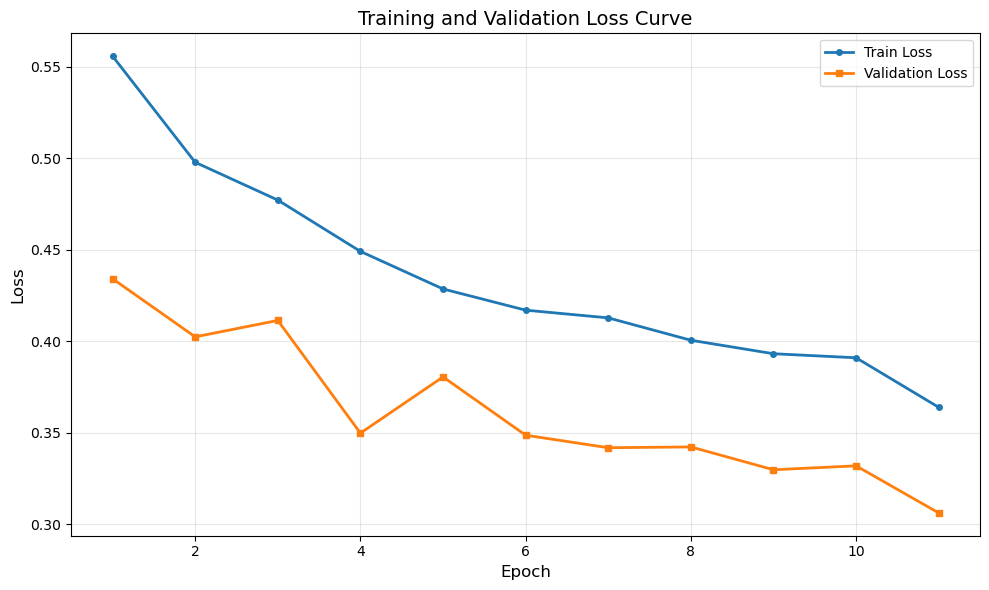

Learning curve displayed!


In [9]:
# ───────────────────────────────
# 学習曲線の描画（修正版）
# ───────────────────────────────
plt.figure(figsize=(10, 6))

# 実際に記録されたデータ数に合わせて横軸を作る
epochs_actual = len(train_losses)  # または len(val_losses) でもOK（本来は同じはず）

plt.plot(range(1, epochs_actual + 1), train_losses, 
         label='Train Loss', marker='o', linewidth=2, markersize=4)
plt.plot(range(1, epochs_actual + 1), val_losses, 
         label='Validation Loss', marker='s', linewidth=2, markersize=4)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training and Validation Loss Curve', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# 保存
os.makedirs("results", exist_ok=True)
curve_path = "results/learning_curve.png"
plt.savefig(curve_path, dpi=150, bbox_inches='tight')
print(f"Learning curve saved to {curve_path}")

# 表示
plt.show()
print("Learning curve displayed!")

In [8]:
# ───────────────────────────────
# 学習曲線データをJSONファイルに保存
# ───────────────────────────────
os.makedirs("results", exist_ok=True)
metrics_data = {
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_accs': train_accs,
    'val_accs': val_accs,
    'epochs': epochs,
    'batch_size': batch_size,
    'learning_rate': lr,
    'num_points': num_points
}

json_path = "results/training_metrics.json"
with open(json_path, 'w') as f:
    json.dump(metrics_data, f, indent=4)
print(f"Training metrics saved to {json_path}")

Training metrics saved to results/training_metrics.json


In [1]:
# ============================
#   点群読み込み関数
# ============================
def load_pointcloud(filepath):
    """
    SemanticSTF/KITTI系の .bin ファイルを読み込み、range特徴量を追加
    → (N, 5): x, y, z, intensity, range
    """
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"File not found: {filepath}")

    if filepath.endswith(".bin"):
        # 5列として読んで余分は捨てる → 4列に強制整形
        with open(filepath, "rb") as f:
            pc = np.fromfile(f, dtype=np.float32).reshape(-1, 5)[:, :4]

        # intensity を 0~1 に正規化
        pc[:, 3] = pc[:, 3] / 255.0
        
        # range を計算して追加
        range_vals = np.sqrt(pc[:, 0]**2 + pc[:, 1]**2 + pc[:, 2]**2)
        range_vals = range_vals.reshape(-1, 1)
        pc = np.concatenate([pc, range_vals], axis=1)  # (N, 5)

    elif filepath.endswith(".npy"):
        pc = np.load(filepath)
        if pc.shape[1] < 4:
            raise ValueError("npy file must have at least 4 channels (x,y,z,intensity)")
        pc = pc[:, :4].astype(np.float32)
        
        # .npyでintensityが0~255のままの可能性が高いので正規化
        if pc[:, 3].max() > 1.1:
            pc[:, 3] = pc[:, 3] / 255.0
        
        # range を計算して追加
        range_vals = np.sqrt(pc[:, 0]**2 + pc[:, 1]**2 + pc[:, 2]**2)
        range_vals = range_vals.reshape(-1, 1)
        pc = np.concatenate([pc, range_vals], axis=1)  # (N, 5)

    else:
        raise ValueError(f"Unsupported file format: {filepath}")

    return pc.astype(np.float32)


# ============================
#   ランダムサンプリング
# ============================
def sample_points(pc, num_points=32768):
    """
    点群とラベルを同じインデックスでサンプリングするため、idxも返す
    """
    N = pc.shape[0]
    if N == 0:
        return np.zeros((num_points, 5), dtype=np.float32), np.zeros(
            num_points, dtype=np.int64
        )

    if N >= num_points:
        idx = np.random.choice(N, num_points, replace=False)
    else:
        idx = np.random.choice(N, num_points, replace=True)

    return pc[idx], idx


# ============================
#   テスト評価関数
# ============================
def evaluate_test_set(model, test_loader, device):
    """
    テストデータセットに対して推論を実行し、混同行列と再現率を計算
    
    Args:
        model: 学習済みモデル
        test_loader: テストデータのDataLoader
        device: 実行デバイス (cuda/cpu)
    
    Returns:
        conf_matrix: 混同行列 (2x2 numpy array)
        recall: 再現率 (float)
    """
    model.eval()
    
    all_preds = []
    all_labels = []
    
    print("\n=== テストデータでの評価を開始 ===")
    
    with torch.no_grad():
        for points, labels in tqdm(test_loader, desc="推論中", unit="batch"):
            points = points.to(device)  # (B, N, 5)
            labels = labels.to(device)  # (B, N)
            
            # モデルの推論
            logits = model(points)  # (B, N, 2)
            preds = logits.argmax(dim=-1)  # (B, N)
            
            # バッチ内の全点を収集
            all_preds.append(preds.cpu().numpy().flatten())
            all_labels.append(labels.cpu().numpy().flatten())
    
    # 全データを結合
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    
    # 混同行列を計算
    conf_matrix = confusion_matrix(all_labels, all_preds, labels=[0, 1])
    
    # 再現率を計算 (クラス1=ノイズ点に対する再現率)
    recall = recall_score(all_labels, all_preds, pos_label=1, zero_division=0)
    
    return conf_matrix, recall


# ============================
#   結果表示関数
# ============================
def print_evaluation_results(conf_matrix, recall):
    """
    混同行列と再現率を見やすく表示
    
    Args:
        conf_matrix: 混同行列 (2x2 numpy array)
        recall: 再現率 (float)
    """
    print("\n" + "="*50)
    print("評価結果")
    print("="*50)
    
    print("\n【混同行列】")
    print("                予測")
    print("              0 (正常)  1 (ノイズ)")
    print(f"実際 0 (正常)   {conf_matrix[0, 0]:8d}  {conf_matrix[0, 1]:8d}")
    print(f"     1 (ノイズ) {conf_matrix[1, 0]:8d}  {conf_matrix[1, 1]:8d}")
    
    # 各指標を計算
    tn, fp, fn, tp = conf_matrix.ravel()
    
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print("\n【評価指標】")
    print(f"Accuracy (精度):     {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Recall (再現率):     {recall:.4f} ({recall*100:.2f}%)")
    print(f"Precision (適合率):  {precision:.4f} ({precision*100:.2f}%)")
    print(f"F1 Score:           {f1_score:.4f}")
    
    print("\n【詳細統計】")
    print(f"True Positives (TP):  {tp:8d}  (ノイズを正しくノイズと予測)")
    print(f"True Negatives (TN):  {tn:8d}  (正常を正しく正常と予測)")
    print(f"False Positives (FP): {fp:8d}  (正常を誤ってノイズと予測)")
    print(f"False Negatives (FN): {fn:8d}  (ノイズを誤って正常と予測)")
    print("="*50 + "\n")

In [2]:
def run_inference(
    data_root: str = "./SemanticSTF",
    checkpoint: str = "checkpoints/pointnet2_best.pth",
    num_points: int = 16384,
    batch_size: int = 2,
    num_workers: int = 4,
    save_results: bool = False,
    output_path: str = "results/test_results.txt",
):
    """
    推論のメイン処理（argparse を使わない版）
    """
    print(f"使用デバイス: {device}")

    # モデルの読み込み
    print(f"\nモデルを読み込み中: {checkpoint}")
    model = PointNet2(in_dim=5, num_classes=2, num_points=num_points).to(device)
    model.load_state_dict(torch.load(checkpoint, map_location=device))
    model.eval()
    print("モデルの読み込み完了")

    # テストデータセットの準備
    print(f"\nテストデータセットを準備中: {data_root}")
    test_dataset = SemanticSTFDataset(
        root_dir=data_root,
        split="test",
        num_points=num_points,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    print(f"テストデータ数: {len(test_dataset)} samples")

    # 評価実行
    conf_matrix, recall = evaluate_test_set(model, test_loader, device)

    # 結果表示
    print_evaluation_results(conf_matrix, recall)

    # 結果をファイルに保存（オプション）
    if save_results:
        os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)
        with open(output_path, "w") as f:
            f.write("混同行列:\n")
            f.write(f"{conf_matrix}\n\n")
            f.write(f"再現率 (Recall): {recall:.4f}\n")
        print(f"結果を保存しました: {output_path}")

In [6]:
run_inference()

使用デバイス: cuda

モデルを読み込み中: checkpoints/pointnet2_best.pth
モデルの読み込み完了

テストデータセットを準備中: ./SemanticSTF
テストデータ数: 326 samples

=== テストデータでの評価を開始 ===


推論中: 100%|██████████| 163/163 [03:38<00:00,  1.34s/batch]



評価結果

【混同行列】
                予測
              0 (正常)  1 (ノイズ)
実際 0 (正常)    4436688    566281
     1 (ノイズ)    76963    261252

【評価指標】
Accuracy (精度):     0.8796 (87.96%)
Recall (再現率):     0.7724 (77.24%)
Precision (適合率):  0.3157 (31.57%)
F1 Score:           0.4482

【詳細統計】
True Positives (TP):    261252  (ノイズを正しくノイズと予測)
True Negatives (TN):   4436688  (正常を正しく正常と予測)
False Positives (FP):   566281  (正常を誤ってノイズと予測)
False Negatives (FN):    76963  (ノイズを誤って正常と予測)



In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# CUDAメモリの最適化設定
if torch.cuda.is_available():
    torch.cuda.empty_cache()  # キャッシュをクリア
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print(f"Initial Allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
    print(f"Initial Reserved: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")

Using: cuda
GPU Memory: 6.00 GB
Initial Allocated: 0.00 GB
Initial Reserved: 0.00 GB
